In [231]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

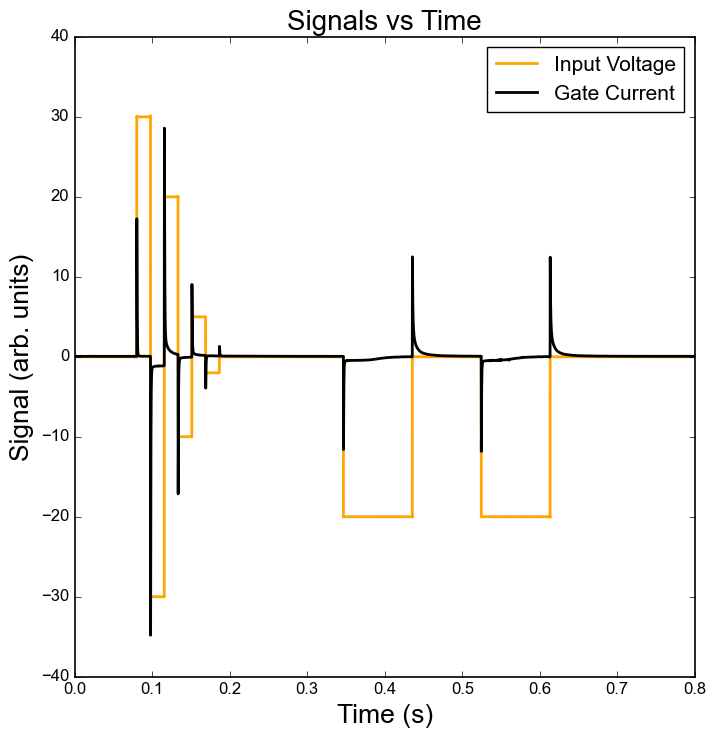

In [232]:
data1 = np.loadtxt("./Data_20262904/20262904003.dat")
data2 = np.loadtxt("./Data_20262904/20262904003.snp")

R1 = 1e6
R2 = 1e5  # Resistance in ohms
Amp = 20

t = data1[:, 0]
V_R = data1[:, 1]
main_trigger = data1[:, 2]
V_in = data1[:, 3]*(-Amp)
second_trigger = data1[:, 4]
I = data1[:, 5]

V_C = V_in - V_R/R2 *(R1 + R2)

plt.figure(figsize=(8, 8))
plt.plot(t, V_in, label='Input Voltage', lw = 2, color = 'orange')
plt.plot(t, V_R*10, label='Gate Current', lw = 2, color = 'k')
# plt.plot(t, V_C, label='V_C', lw = 1.5, color = 'orange')
# plt.plot(t, main_trigger, label='Main Trigger', lw = 1.5, color = 'red')
# plt.plot(t, second_trigger, label='Second Trigger', lw = 1.5, color = 'black')
plt.xlabel('Time (s)', fontsize=19)
plt.ylabel('Signal (arb. units)', fontsize=19)
# plt.xlim(0.02, 0.22)

plt.title('Signals vs Time', fontsize=20)
plt.legend(frameon=True, numpoints=1, fontsize=15)
# plt.savefig('DLTS.eps', format='eps', bbox_inches='tight')
plt.show()


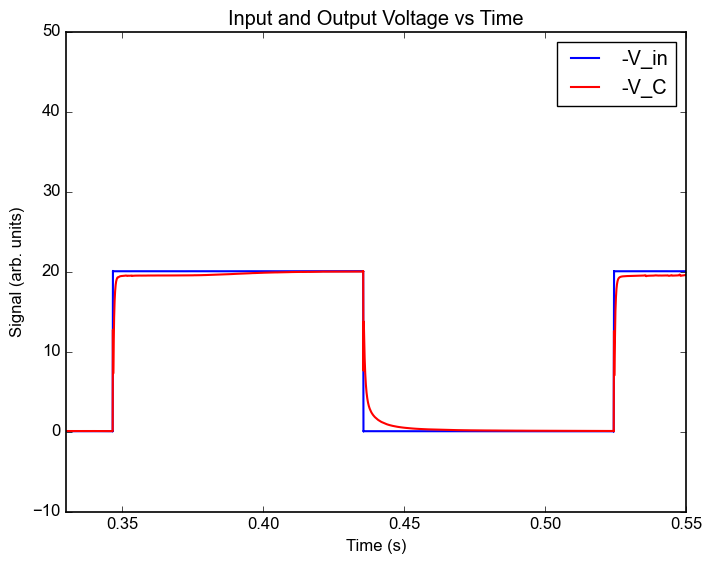

In [233]:
plt.plot(t, -V_in, label='-V_in', lw = 1.5, color = 'blue')
# plt.plot(t, V_R*10, label='V_R', lw = 1.5, color = 'green')
plt.plot(t, -V_C, label='-V_C', lw = 1.5, color = 'red')
# plt.plot(t, main_trigger, label='Main Trigger', lw = 1.5, color = 'red')
# plt.plot(t, second_trigger, label='Second Trigger', lw = 1.5, color = 'black')
plt.xlabel('Time (s)')
plt.ylabel('Signal (arb. units)')
plt.xlim(0.33, 0.55)
plt.ylim(-10, 50)

plt.title('Input and Output Voltage vs Time')
plt.legend()
plt.show()

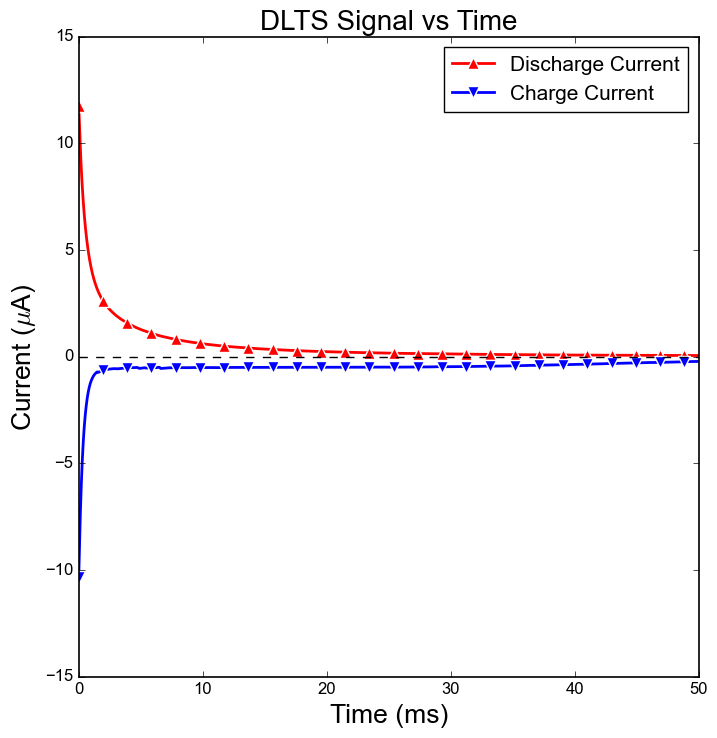

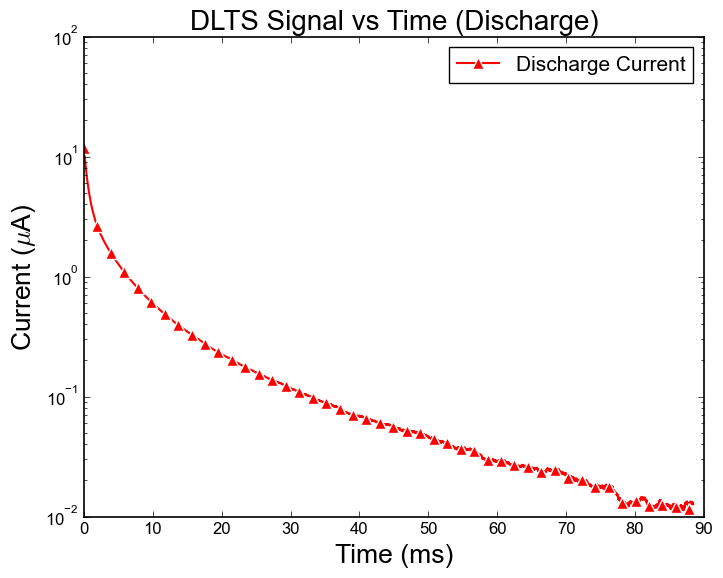

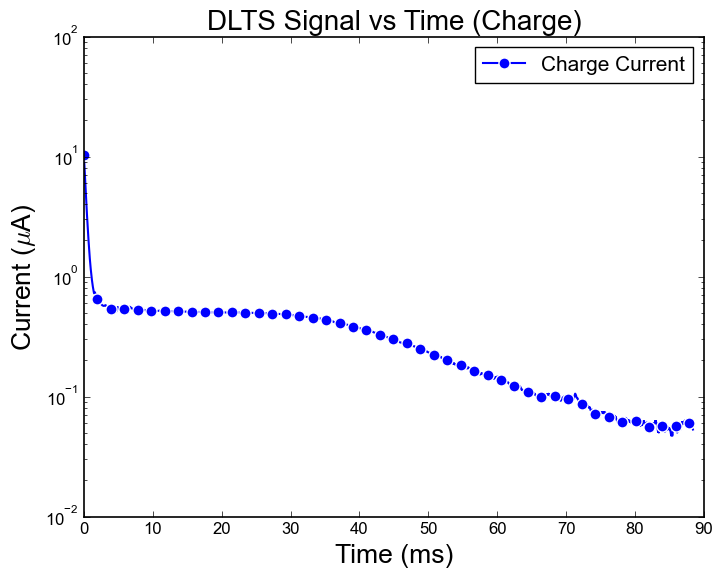

In [234]:
t = data2[:, 0]
V_discharge = data2[:, 2]
V_charge = data2[:, 1]
I_discharge = V_discharge/R2
I_charge = V_charge/R2

plt.figure(figsize=(8, 8))
plt.plot(t*1e3, I_discharge*1e6, label='Discharge Current', color='red', ls='-', lw = 2, marker='^', markevery=200,markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.plot(t*1e3, I_charge*1e6, label='Charge Current', color='blue', ls='-', lw = 2, marker='v', markevery=200,markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.axhline(y=0.0, color='black', ls='--', lw=1)
plt.xlabel('Time (ms)', fontsize=19)
plt.ylabel(r'Current ($\mu$A)', fontsize=19)
plt.title('DLTS Signal vs Time', fontsize=20)
plt.xlim(0.00, 50)
# plt.ylim(-3, 3)
plt.legend(frameon=True, numpoints=1, fontsize=15)
# plt.savefig('DLTS_current.eps', format='eps', bbox_inches='tight')
plt.show()

plt.semilogy(t*1e3, I_discharge*1e6, label='Discharge Current', color='red', ls='-', lw = 1.5, marker='^', markevery=200,markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.xlabel('Time (ms)', fontsize=19)
plt.ylabel(r'Current ($\mu$A)', fontsize=19)
plt.title('DLTS Signal vs Time (Discharge)', fontsize=20)
plt.legend(frameon=True, numpoints=1, fontsize=15)
plt.show()

plt.semilogy(t*1e3, -I_charge*1e6, label='Charge Current', color='blue', ls='-', lw = 1.5, marker='o', markevery=200,markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.xlabel('Time (ms)', fontsize=19)
plt.ylabel(r'Current ($\mu$A)', fontsize=19)
plt.title('DLTS Signal vs Time (Charge)', fontsize=20)
plt.legend(frameon=True, numpoints=1, fontsize=15)
plt.show()


a = 0.897 ± 0.0104
b = 0.00172 ± 2.93e-05
R^2 = 0.906


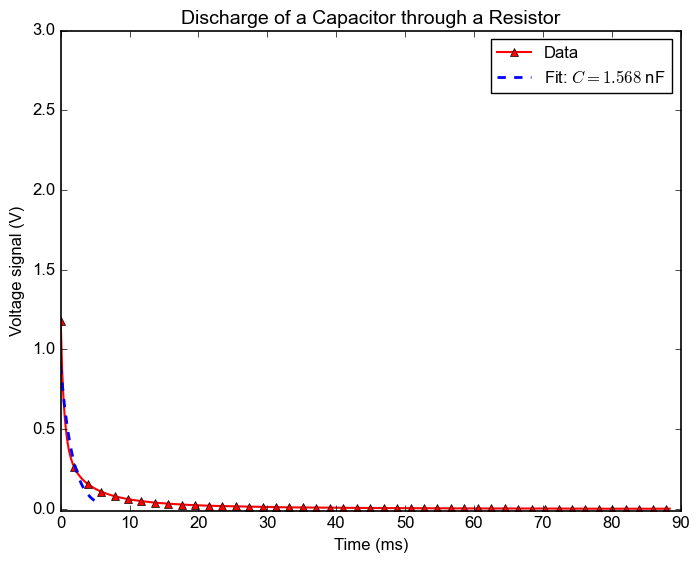

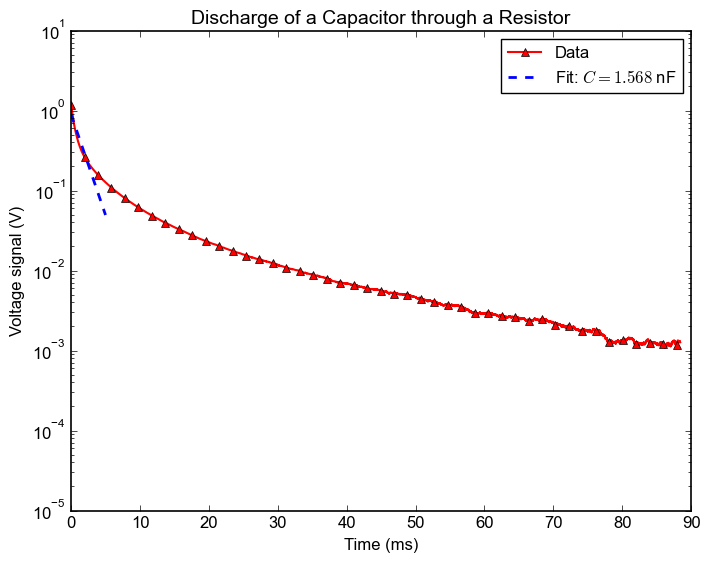

In [235]:
def func(x, a, b):
    return a * np.exp(-x / b)


# Fit the exponential decay in the requested time window
mask = np.isfinite(t) & np.isfinite(V_discharge) & (t >= 0.000) & (t <= 0.005)
t_fit = t[mask] - t[mask][0]

C_actual = 0.1e-9  # Actual capacitance in farads
p0 = [np.max(V_discharge[mask]), C_actual * (R1 + R2)]

popt, pcov = curve_fit(func, t_fit, V_discharge[mask], p0 = p0, maxfev=10000)
sigma_fit = func(t_fit, *popt)
a, b = popt


# Coefficient of determination
ss_res = np.sum((V_discharge[mask] - sigma_fit) ** 2)
ss_tot = np.sum((V_discharge[mask] - np.mean(V_discharge[mask])) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr
C = b / (R1 + R2)
C_err = b_err / (R1 + R2)  

print(f"a = {a:.3g} ± {a_err:.3g}")
print(f"b = {b:.3g} ± {b_err:.3g}")
print(f"R^2 = {r2:.3f}")


x = np.linspace(t[mask].min(), t[mask].max(), 100)
plt.plot(t*1e3, V_discharge, '^', label='Data', color='red', markersize=6, ls='-', lw = 1.5, markevery=200)
plt.plot(x*1e3, func(x - t[mask][0], *popt), lw=2, label=rf'Fit: $C={C*1e9:.3f}$ nF', color='blue', linestyle='--')
plt.xlabel(r"Time (ms)")
plt.ylabel(r"Voltage signal (V)")
plt.xlim(0.00, 90)
plt.ylim(-0.01, 3)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=12)
plt.title("Discharge of a Capacitor through a Resistor", fontsize=14)
# plt.savefig("conductance_PS9.eps", format='eps', bbox_inches='tight')
plt.show()

plt.semilogy(t*1e3, V_discharge, '^', label='Data', color='red', markersize=6, ls='-', lw = 1.5, markevery=200)
plt.semilogy(x*1e3, func(x - t[mask][0], *popt), lw=2, label=rf'Fit: $C={C*1e9:.3f}$ nF', color='blue', linestyle='--')
plt.xlabel(r"Time (ms)")
plt.ylabel(r"Voltage signal (V)")
plt.xlim(0.00, 90)
plt.ylim(1e-5, 1e1)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=12)
plt.title("Discharge of a Capacitor through a Resistor", fontsize=14)
# plt.savefig("conductance_PS9.eps", format='eps', bbox_inches='tight')
plt.show()

a = -0.979 ± 0.00956
b = 0.000443 ± 6.2e-06
R^2 = 0.981


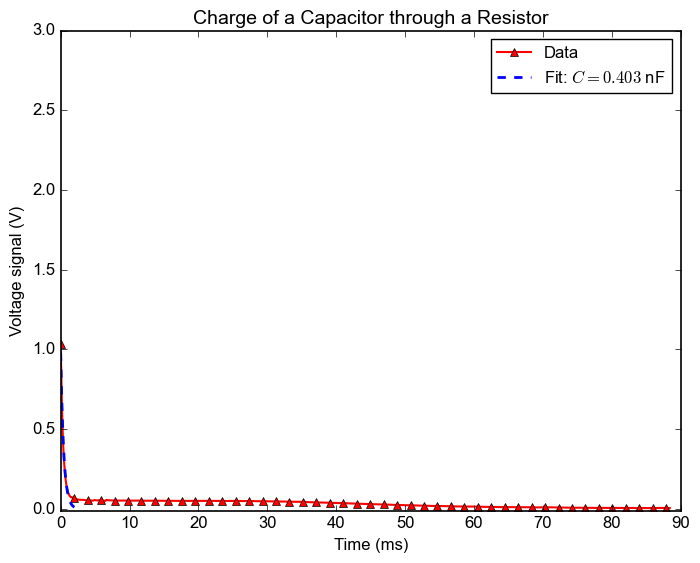

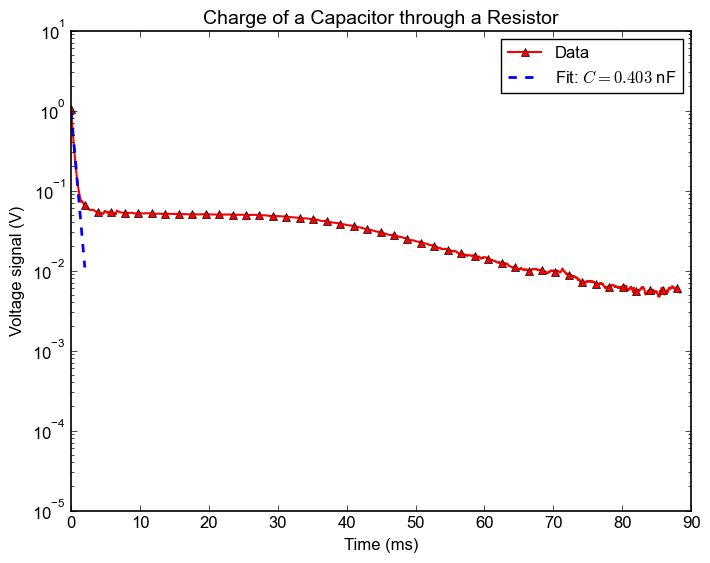

In [236]:
def func(x, a, b):
    return a * np.exp(-x / b)


# Fit the exponential decay in the requested time window
mask = np.isfinite(t) & np.isfinite(V_charge) & (t >= 0.000) & (t <= 0.002)
t_fit = t[mask] - t[mask][0]

C_actual = 0.1e-9  # Actual capacitance in farads
p0 = [np.max(V_charge[mask]), C_actual * (R1 + R2)]

popt, pcov = curve_fit(func, t_fit, V_charge[mask], p0 = p0, maxfev=10000)
sigma_fit = func(t_fit, *popt)
a, b = popt


# Coefficient of determination
ss_res = np.sum((V_charge[mask] - sigma_fit) ** 2)
ss_tot = np.sum((V_charge[mask] - np.mean(V_charge[mask])) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr
C = b / (R1 + R2)
C_err = b_err / (R1 + R2)  

print(f"a = {a:.3g} ± {a_err:.3g}")
print(f"b = {b:.3g} ± {b_err:.3g}")
print(f"R^2 = {r2:.3f}")


x = np.linspace(t[mask].min(), t[mask].max(), 100)
plt.plot(t*1e3, -V_charge, '^', label='Data', color='red', markersize=6, ls='-', lw = 1.5, markevery=200)
plt.plot(x*1e3, -func(x - t[mask][0], *popt), lw=2, label=rf'Fit: $C={C*1e9:.3f}$ nF', color='blue', linestyle='--')
plt.xlabel(r"Time (ms)")
plt.ylabel(r"Voltage signal (V)")
plt.xlim(0.00, 90)
plt.ylim(-0.01, 3)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=12)
plt.title("Charge of a Capacitor through a Resistor", fontsize=14)
# plt.savefig("conductance_PS9.eps", format='eps', bbox_inches='tight')
plt.show()

plt.semilogy(t*1e3, -V_charge, '^', label='Data', color='red', markersize=6, ls='-', lw = 1.5, markevery=200)
plt.semilogy(x*1e3, -func(x - t[mask][0], *popt), lw=2, label=rf'Fit: $C={C*1e9:.3f}$ nF', color='blue', linestyle='--')
plt.xlabel(r"Time (ms)")
plt.ylabel(r"Voltage signal (V)")
plt.xlim(0.00, 90)
plt.ylim(1e-5, 1e1)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=12)
plt.title("Charge of a Capacitor through a Resistor", fontsize=14)
# plt.savefig("conductance_PS9.eps", format='eps', bbox_inches='tight')
plt.show()

In [237]:
Q_discharge = 0
Q_charge = 0
for i in range(1, len(t)):
    dt = t[i] - t[i-1]
    Q_discharge += I_discharge[i] * dt
    Q_charge += I_charge[i] * dt
    Q_trap = Q_charge + Q_discharge

U0 = 40
C_discharge = np.abs(Q_discharge / (U0 - 5.9))
C_charge = np.abs(Q_charge / (U0 - 5.9))

print(Q_charge)
print(Q_discharge)
print(Q_trap)

print(C_charge)
print(C_discharge)

-3.0404374329075164e-08
2.7310486691045974e-08
-3.0938876380291903e-09
8.9162388061804e-10
8.008940378605857e-10


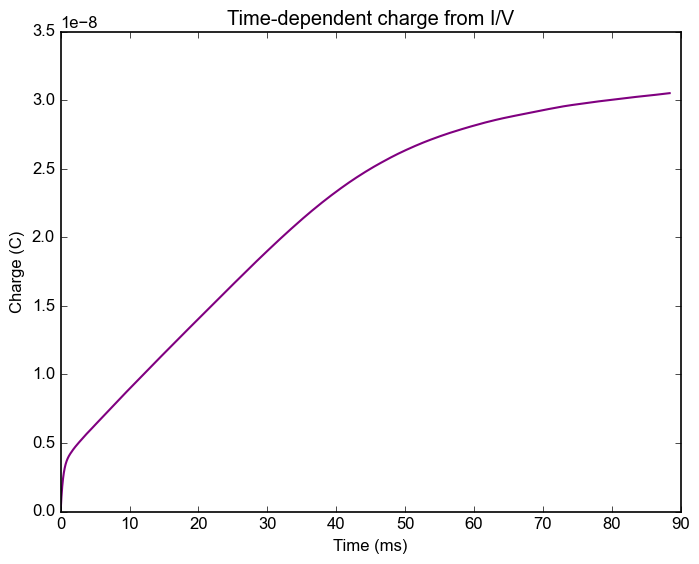

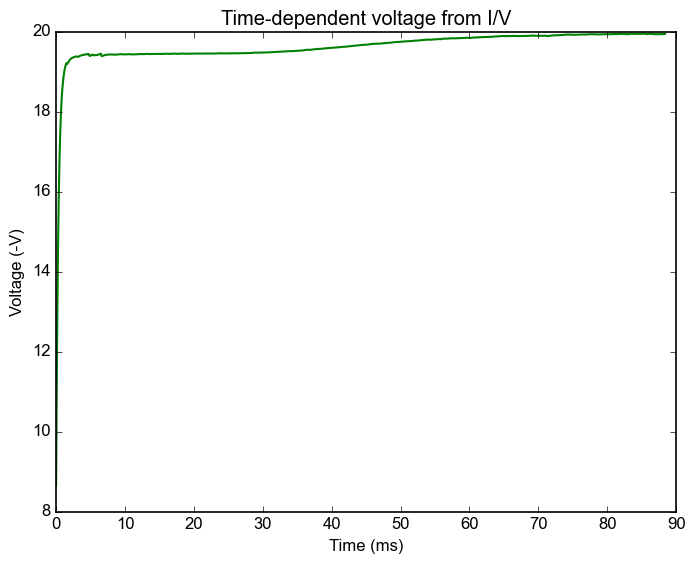

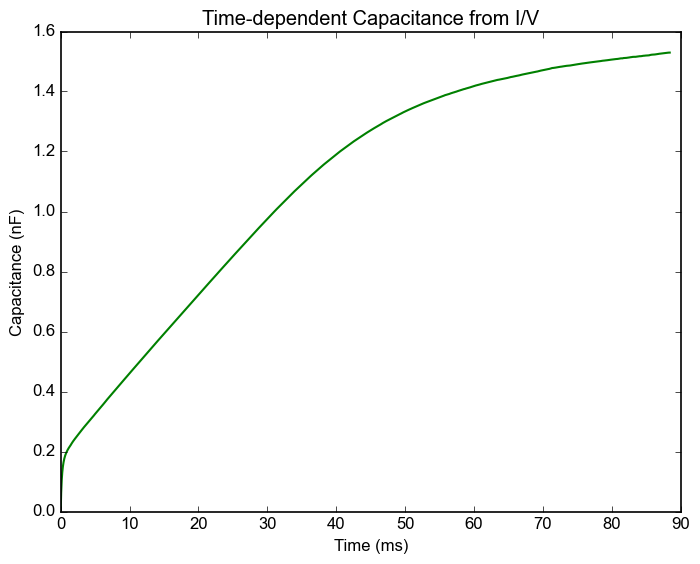

In [238]:
# Time-dependent capacitance from I/V
U0 = -20
R = R2 + R1

Q_charge = np.zeros_like(t)

for i in range(len(I_charge)-1):
    dt = t[i+1] - t[i]
    Q_charge[i+1] = Q_charge[i] + I_charge[i] * dt


plt.plot(t*1e3, -Q_charge, lw=1.5, color='purple', label='Q(t)')
plt.xlabel('Time (ms)')
plt.ylabel('Charge (C)')
plt.title('Time-dependent charge from I/V')
# plt.legend(frameon=True)
plt.show()

plt.plot(t*1e3, -(U0 - R*I_charge), lw=1.5, color='green', label='C(t)')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (-V)')
plt.title('Time-dependent voltage from I/V')
plt.show()

plt.plot(t*1e3, Q_charge/(U0 - R*I_charge)*1e9, lw=1.5, color='green', label='C(t)')
plt.xlabel('Time (ms)')
plt.ylabel('Capacitance (nF)')
plt.title('Time-dependent Capacitance from I/V')
plt.show()

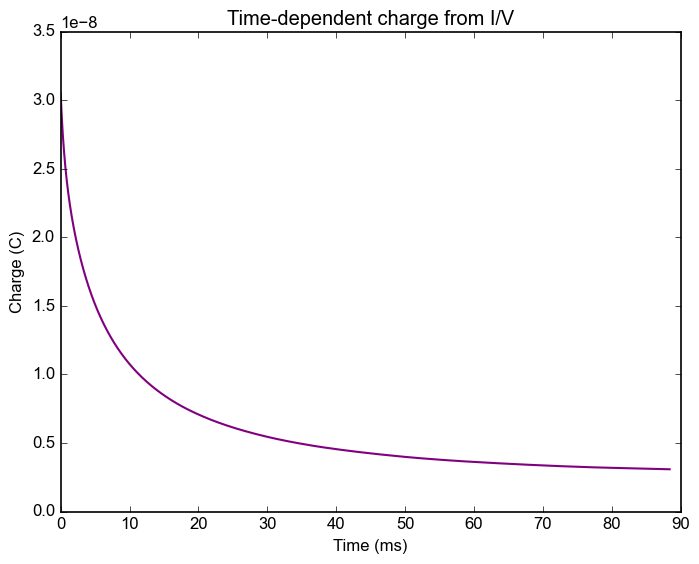

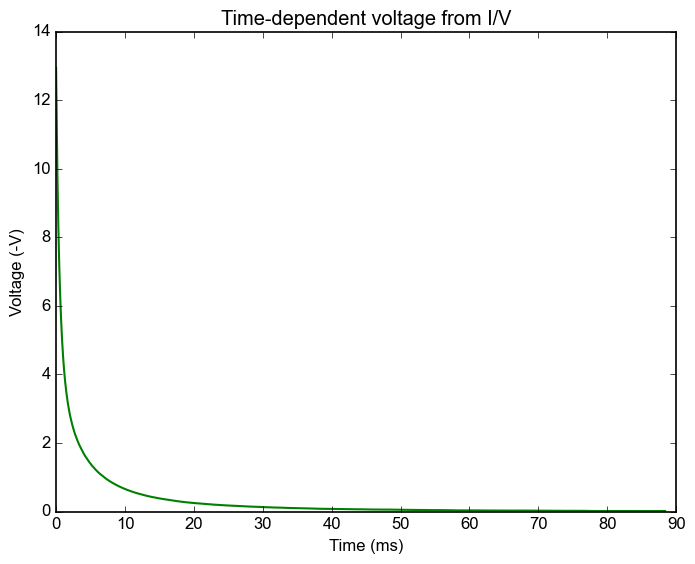

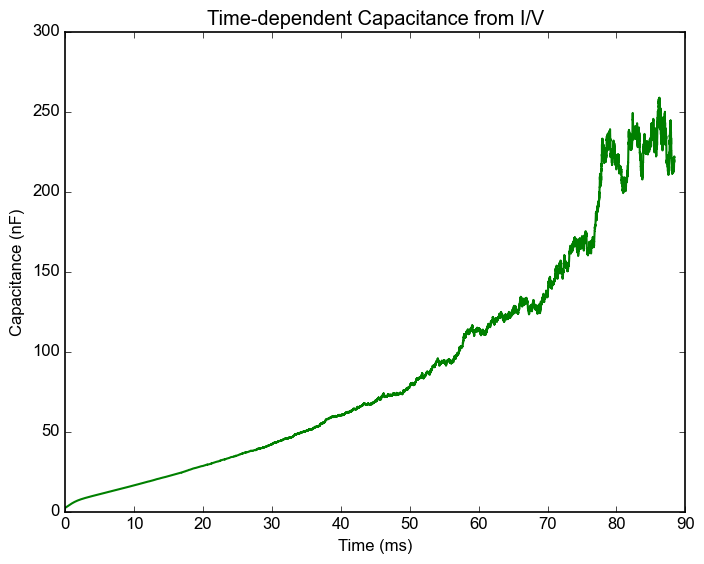

In [239]:
# Time-dependent capacitance from I/V
U0 = -40
R = R2 + R1

Q_discharge = np.zeros_like(t)

for i in range(len(I_discharge)-1):
    dt = t[i+1] - t[i]
    Q_discharge[i+1] = Q_discharge[i] + I_discharge[i] * dt

Q = -Q_charge[-1]- Q_discharge
plt.plot(t*1e3,Q, lw=1.5, color='purple', label='Q(t)')
plt.xlabel('Time (ms)')
plt.ylabel('Charge (C)')
plt.title('Time-dependent charge from I/V')
# plt.legend(frameon=True)
plt.show()

plt.plot(t*1e3, R*I_discharge, lw=1.5, color='green', label='C(t)')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (-V)')
plt.title('Time-dependent voltage from I/V')
plt.show()

plt.plot(t*1e3, Q/(R*I_discharge)*1e9, lw=1.5, color='green', label='C(t)')
plt.xlabel('Time (ms)')
plt.ylabel('Capacitance (nF)')
plt.title('Time-dependent Capacitance from I/V')
plt.show()